## Indlæser masterdatasættet

In [40]:
import pandas as pd
import numpy as np
import os
import statsmodels.formula.api as smf

BASE = "/Users/PC/Documents/Speciale/Analyse/Speciale"
CLEAN_DIR = os.path.join(BASE, "clean")

master = pd.read_csv(os.path.join(CLEAN_DIR, "master_monthly.csv"))
master["month"] = pd.to_datetime(master["month"])

def stjerner(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""

In [41]:
master["dkk_ret"] = master["USDDKK"].pct_change()
master["usd_dkk_ret"] = master["dkk_ret"]
master["eur_ret"] = master["EURUSD"].pct_change()

master["vwretd_q"]      = np.log(1 + master["vwretd"]).rolling(3).sum()
master["sprtrn_q"]      = np.log(1 + master["sprtrn"]).rolling(3).sum()
master["bond_ret_q"]    = np.log(1 + master["bond_ret"]).rolling(3).sum()
master["usd_dkk_ret_q"] = np.log(1 + master["usd_dkk_ret"]).rolling(3).sum()

print("corr(usd_dkk_ret, eur_ret):", master["usd_dkk_ret"].corr(master["eur_ret"]).round(3))

corr(usd_dkk_ret, eur_ret): -0.999


In [42]:
# USD/DKK-afkast: grundlaget for hedge ratio og korrelation (dansk investor)
master["dkk_ret"] = (1 / master["USDDKK"]).pct_change()
master["usd_dkk_ret"] = -master["dkk_ret"]   # USD's afkast set fra en dansker. $R_{FX}$ i Campbell (2016) og i min analyse.

# (valgfrit) EUR til robusthedstjek pga. fastkurspolitikken
master["eur_ret"] = master["EURUSD"].pct_change() # Til robusthedstjek: EUR/USD-afkast (EUR's afkast set fra en dansker)

### Dollarens afdækningsegenskab over tid

In [43]:
# Rullende korrelationer
win = 36
# Samme definitioner som i hedge ratio: USD/DKK og US-aktier
master["corr_usd_eq"] = master["usd_dkk_ret"].rolling(win).corr(master["vwretd"])

# tjek
print(master[["month","corr_usd_eq"]].dropna().head(3))
print(master[["month","corr_usd_eq"]].dropna().tail(6))

        month  corr_usd_eq
36 2018-01-31    -0.051652
37 2018-02-28    -0.120321
38 2018-03-31    -0.082606
         month  corr_usd_eq
126 2025-07-31    -0.322247
127 2025-08-31    -0.306267
128 2025-09-30    -0.242871
129 2025-10-31    -0.242294
130 2025-11-30    -0.198500
131 2025-12-31    -0.279249


In [44]:
# 1) usd_dkk_ret bør være næsten spejlbillede af eur_ret (kronen følger euroen)
#    Når dollaren styrkes: EUR/USD falder (eur_ret<0) OG usd_dkk_ret>0 -> korrelation ~ -1
print("corr(usd_dkk_ret, eur_ret):", master["usd_dkk_ret"].corr(master["eur_ret"]).round(3))

# 2) Fuld-periode korrelation bør være negativ (matcher h* < 1)
print("corr(usd_dkk_ret, vwretd):", master["usd_dkk_ret"].corr(master["vwretd"]).round(3))

corr(usd_dkk_ret, eur_ret): -1.0
corr(usd_dkk_ret, vwretd): -0.254


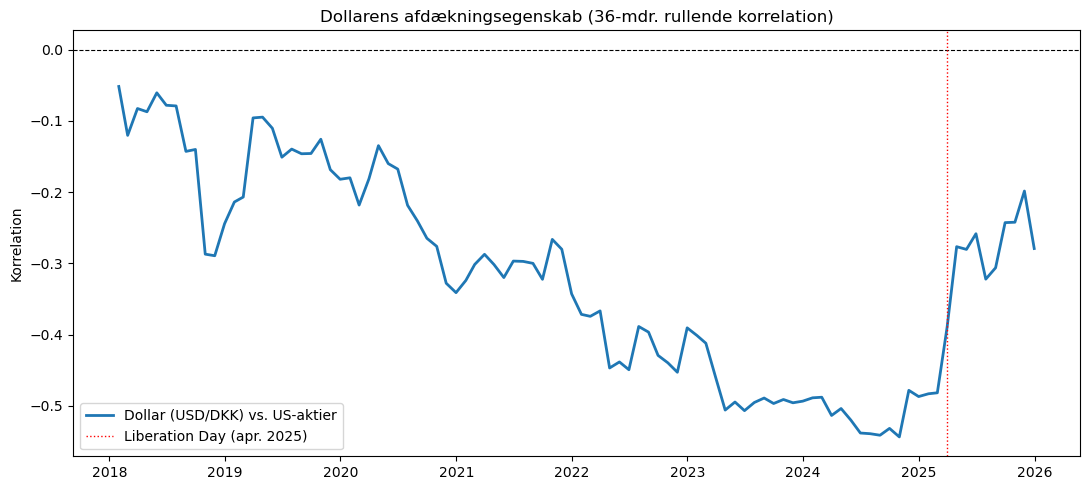

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,5))
d = master.dropna(subset=["corr_usd_eq"])
ax.plot(d["month"], d["corr_usd_eq"], label="Dollar (USD/DKK) vs. US-aktier", lw=2)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(pd.Timestamp("2025-04-01"), color="red", lw=1, ls=":", label="Liberation Day (apr. 2025)")
ax.set_title(f"Dollarens afdækningsegenskab ({win}-mdr. rullende korrelation)")
ax.set_ylabel("Korrelation")
ax.legend()
plt.tight_layout()
plt.show()

Plottet viser om dollarens negative samvariation med US-aktier ændrer sig over tid.

In [46]:
def hedge_ratio(asset_ret, fx_ret, data):
    d = data.dropna(subset=[asset_ret, fx_ret])
    cov = d[asset_ret].cov(d[fx_ret])
    var = d[fx_ret].var()
    return 1 + cov / var

print("=== h* på kvartalsvise, overlappende afkast ===")
for navn, col in [("US aktier (CRSP)", "vwretd_q"), ("S&P 500", "sprtrn_q"), ("US statsobl.", "bond_ret_q")]:
    h = hedge_ratio(col, "usd_dkk_ret_q", master)
    print(f"{navn}: h* = {h:.3f}")

def hedge_ratio_hac(asset_ret, fx_ret, data, maxlags=6):
    d = data.dropna(subset=[asset_ret, fx_ret]).copy()
    m = smf.ols(f"{asset_ret} ~ {fx_ret}", data=d).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    h_star = 1 + m.params[fx_ret]
    return h_star, m.bse[fx_ret], m.pvalues[fx_ret]

print("\n=== h* med HAC-standardfejl (kvartalsvis) ===")
for navn, col in [("US aktier (CRSP)", "vwretd_q"), ("S&P 500", "sprtrn_q"), ("US statsobl.", "bond_ret_q")]:
    h, se, p = hedge_ratio_hac(col, "usd_dkk_ret_q", master)
    print(f"{navn}: h* = {h:.3f}{stjerner(p)}  (SE={se:.3f}, p={p:.3f})")

=== h* på kvartalsvise, overlappende afkast ===
US aktier (CRSP): h* = 0.409
S&P 500: h* = 0.472
US statsobl.: h* = 0.699

=== h* med HAC-standardfejl (kvartalsvis) ===
US aktier (CRSP): h* = 0.409**  (SE=0.251, p=0.019)
S&P 500: h* = 0.472**  (SE=0.243, p=0.030)
US statsobl.: h* = 0.699***  (SE=0.087, p=0.001)


In [47]:
master["lnTPU"]   = np.log(master["TPU"])
master["lnTPU_z"] = (master["lnTPU"] - master["lnTPU"].mean()) / master["lnTPU"].std()

d = master.dropna(subset=["vwretd_q", "usd_dkk_ret_q", "lnTPU_z"]).copy()
m = smf.ols("vwretd_q ~ usd_dkk_ret_q * lnTPU_z", data=d).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
print(m.summary().tables[1])

                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.0292      0.007      4.118      0.000       0.015       0.043
usd_dkk_ret_q            -0.6380      0.209     -3.055      0.002      -1.047      -0.229
lnTPU_z                   0.0083      0.006      1.343      0.179      -0.004       0.020
usd_dkk_ret_q:lnTPU_z     0.3827      0.136      2.806      0.005       0.115       0.650
